In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

import timm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
device = torch.device("cpu")

In [ ]:
data_dir = "/content/drive/MyDrive/Tomato_leaf_data"

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
dataset = datasets.ImageFolder(data_dir, transform=transform)

class_names = dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['GrayMold', 'Viral', 'Wilt']


In [ ]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset,[train_size,test_size])

train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=16,shuffle=False)

In [ ]:
efficientnet = timm.create_model("efficientnetv2_s", pretrained=False, num_classes=num_classes)

efficientnet.load_state_dict(
    torch.load("/content/drive/MyDrive/efficientnetv2.pth", map_location=device)
)

efficientnet.to(device)
efficientnet.eval()

EfficientNet(
  (conv_stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        

In [ ]:
convnext = timm.create_model("convnext_tiny", pretrained=False, num_classes=num_classes)

convnext.load_state_dict(
    torch.load("/content/drive/MyDrive/conVneXt_Tiny.pth", map_location=device)
)

convnext.to(device)
convnext.eval()

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)


In [ ]:
vit = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=num_classes)

vit.load_state_dict(
    torch.load("/content/drive/MyDrive/vit.pth", map_location=device)
)

vit.to(device)
vit.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
swin = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False, num_classes=num_classes)

swin.load_state_dict(
    torch.load("/content/drive/MyDrive/Swin_Transformer.pth", map_location=device)
)

swin.to(device)
swin.eval()

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [ ]:
#softvotingof3modelsConvNeXt + EfficientNet + ViT
def ensemble_predict(images):

    with torch.no_grad():

        out1 = torch.softmax(convnext(images), dim=1)
        out2 = torch.softmax(efficientnet(images), dim=1)
        out3 = torch.softmax(vit(images), dim=1)

        avg = (out1 + out2 + out3) / 3

    return avg

In [ ]:
correct = 0
total = 0

y_true = []
y_pred = []

for images, labels in test_loader:

    images = images.to(device)
    labels = labels.to(device)

    outputs = ensemble_predict(images)

    _, predicted = torch.max(outputs,1)

    total += labels.size(0)
    correct += (predicted==labels).sum().item()

    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predicted.cpu().numpy())

ensemble_accuracy = 100 * correct / total

print("Hybrid Model Accuracy:", ensemble_accuracy)

Hybrid Model Accuracy: 99.66666666666667


In [ ]:
print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

    GrayMold       0.99      1.00      1.00       188
       Viral       0.99      0.99      0.99       193
        Wilt       1.00      1.00      1.00       219

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



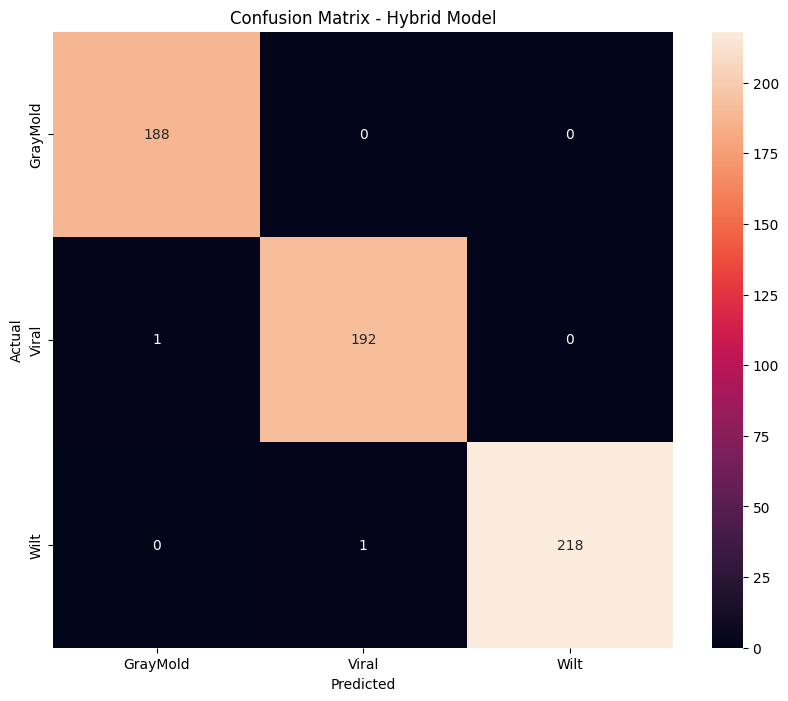

In [ ]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - Hybrid Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

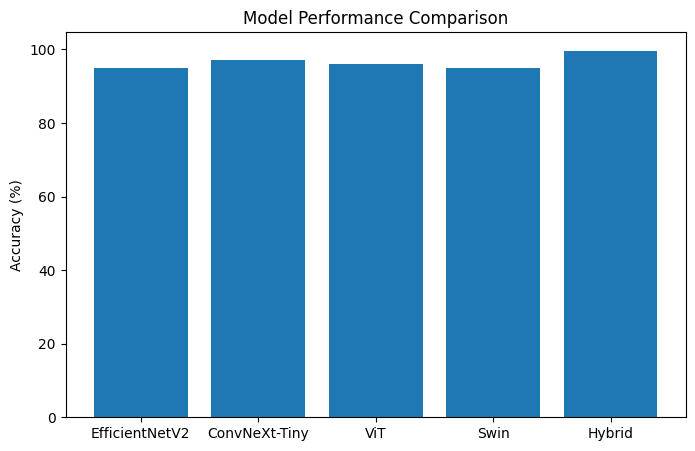

In [ ]:
models = ["EfficientNetV2","ConvNeXt-Tiny","ViT","Swin","Hybrid"]

accuracy = [94.89,97.11,96,95,ensemble_accuracy]

plt.figure(figsize=(8,5))

plt.bar(models,accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Model Performance Comparison")

plt.show()

In [ ]:
torch.save({
    'convnext': convnext.state_dict(),
    'efficientnet': efficientnet.state_dict(),
    'vit': vit.state_dict()
}, "/content/drive/MyDrive/hybrid_model.pth")